In [2]:
# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

# Matplotlib para gráficos
import matplotlib.pyplot as plt

# Para entrada de datos (input)
from tensorflow.keras.layers import Input

In [5]:
# Cargar el dataset
(imagenes_entrenamiento, etiquetas_entrenamiento), (imagenes_prueba, etiquetas_prueba) = datasets.cifar10.load_data()

In [4]:

# Mostrar shapes
print("Shape imágenes entrenamiento:", imagenes_entrenamiento.shape)
print("Shape etiquetas entrenamiento:", etiquetas_entrenamiento.shape)

print("Shape imágenes prueba:", imagenes_prueba.shape)
print("Shape etiquetas prueba:", etiquetas_prueba.shape)

Shape imágenes entrenamiento: (50000, 32, 32, 3)
Shape etiquetas entrenamiento: (50000, 1)
Shape imágenes prueba: (10000, 32, 32, 3)
Shape etiquetas prueba: (10000, 1)


In [6]:
# Normalizar imágenes
imagenes_entrenamiento = imagenes_entrenamiento / 255.0
imagenes_prueba = imagenes_prueba / 255.0

# Verificar valores
print("Valor mínimo entrenamiento:", imagenes_entrenamiento.min())
print("Valor máximo entrenamiento:", imagenes_entrenamiento.max())

Valor mínimo entrenamiento: 0.0
Valor máximo entrenamiento: 1.0


In [7]:
print("Shape de la primera imagen:", imagenes_entrenamiento[0].shape)

Shape de la primera imagen: (32, 32, 3)


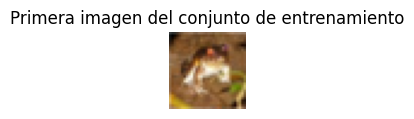

In [10]:

# Mostrar la primera imagen}
plt.figure(figsize=(1,1))
plt.imshow(imagenes_entrenamiento[0])
plt.title("Primera imagen del conjunto de entrenamiento")
plt.axis('off')  # Oculta los ejes
plt.show()

In [11]:
print("Primera etiqueta:", etiquetas_entrenamiento[0])

Primera etiqueta: [6]


In [13]:
imagenes_entrenamiento[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [14]:
import numpy as np

# Obtener valores únicos
valores_unicos = np.unique(etiquetas_entrenamiento)

# Cardinalidad
cardinalidad = len(valores_unicos)

print("Valores únicos:", valores_unicos)
print("Cardinalidad:", cardinalidad)

Valores únicos: [0 1 2 3 4 5 6 7 8 9]
Cardinalidad: 10


In [15]:
clases = ['avion','automovil','pajaro','gato','ciervo','perro', 'rana', 'caballo', 'barco', 'camion']

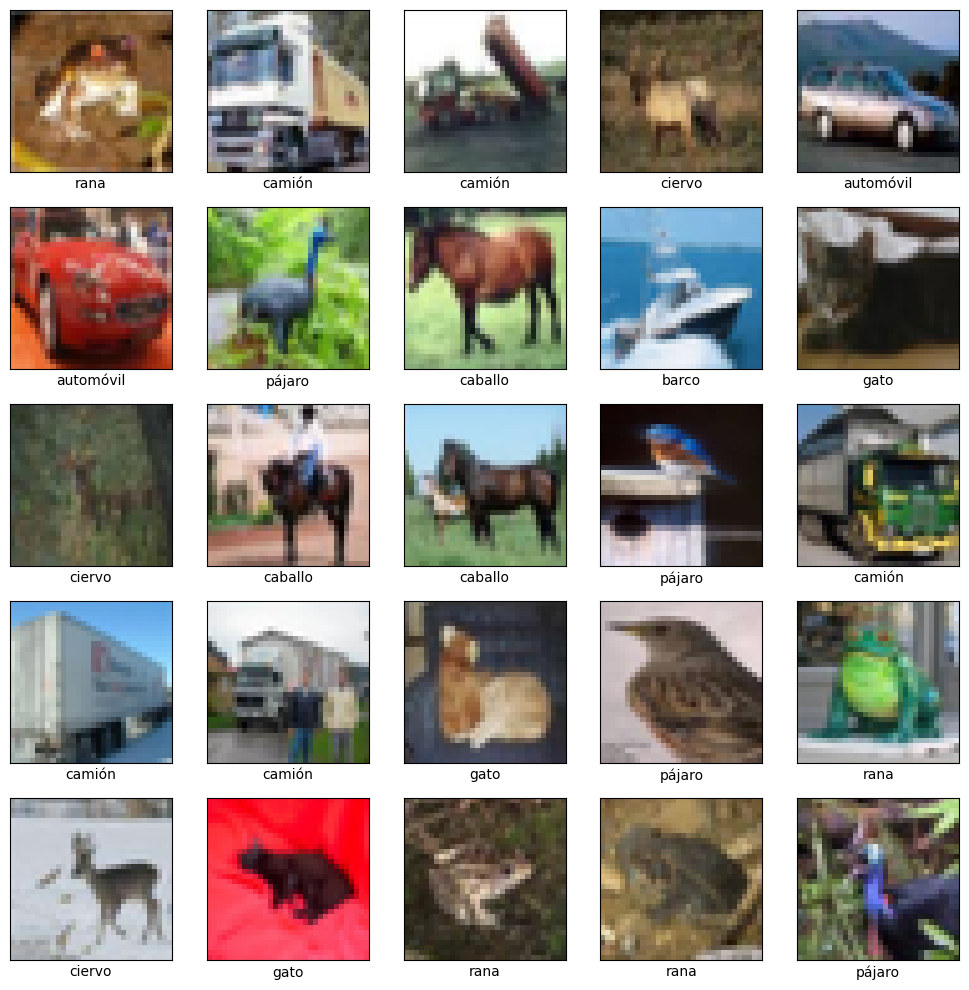

In [16]:
# Nombres de las clases en CIFAR-10
clases = ["avión", "automóvil", "pájaro", "gato", "ciervo",
          "perro", "rana", "caballo", "barco", "camión"]

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(imagenes_entrenamiento[i])
    
    # Quitar ejes y grid
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    # Etiqueta como número
    etiqueta = etiquetas_entrenamiento[i][0]
    
    # Nombre de la clase centrado abajo
    plt.xlabel(clases[etiqueta])

plt.tight_layout()
plt.show()

In [22]:
# Declarar modelo
modelo = models.Sequential()

# Capa convolucional 1
modelo.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)))
modelo.add(layers.MaxPooling2D((2, 2)))

# Capa convolucional 2
modelo.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo.add(layers.MaxPooling2D((2, 2)))


# Aplanar
modelo.add(layers.Flatten())

# Red neuronal (capas densas)
modelo.add(layers.Dense(64, activation='relu'))
modelo.add(layers.Dense(10, activation='softmax'))  # salida

# Resumen del modelo
modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,698 (369.91 KB)

 Trainable params: 94,698 (369.91 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = modelo.fit(
    imagenes_entrenamiento,
    etiquetas_entrenamiento,
    epochs=50,
    validation_split=0.1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4455 - loss: 1.5332 - val_accuracy: 0.5484 - val_loss: 1.2755
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5808 - loss: 1.1870 - val_accuracy: 0.6162 - val_loss: 1.0841
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6327 - loss: 1.0465 - val_accuracy: 0.6446 - val_loss: 1.0140
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6647 - loss: 0.9620 - val_accuracy: 0.6468 - val_loss: 0.9929
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6880 - loss: 0.8986 - val_accuracy: 0.6672 - val_loss: 0.9592
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7065 - loss: 0.8437 - val_accuracy: 0.6820 - val_loss: 0.9448
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7219 - loss: 0.7941 - val_accuracy: 0.6880 - val_loss: 0.9421
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7376 - loss: 0.7525 - 

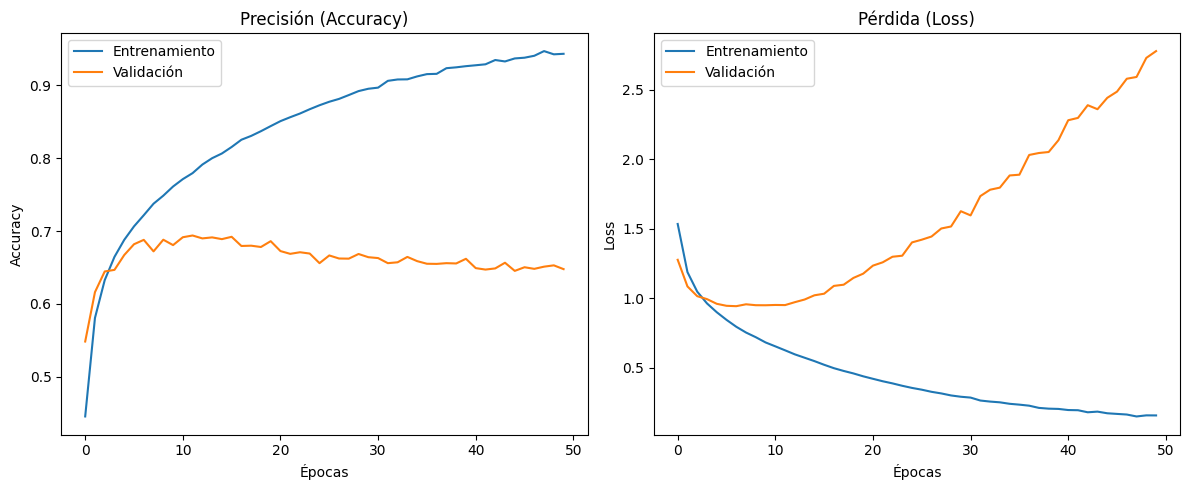

In [24]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


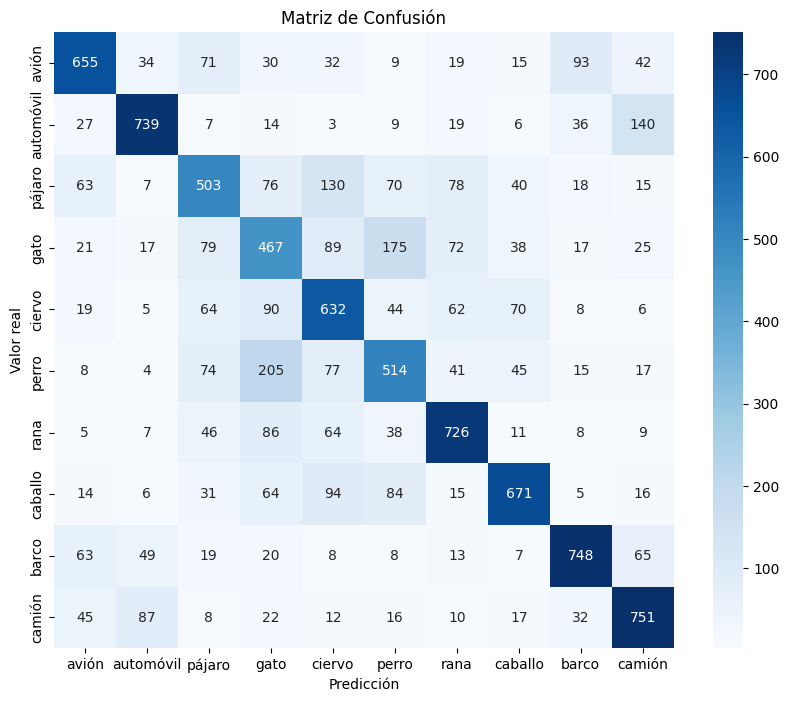

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predecir sobre datos de prueba
predicciones = modelo.predict(imagenes_prueba)

# Convertir probabilidades a clases
y_pred = np.argmax(predicciones, axis=1)

# Etiquetas reales (aplanar)
y_true = etiquetas_prueba.flatten()

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Nombres de clases
clases = ["avión", "automóvil", "pájaro", "gato", "ciervo",
          "perro", "rana", "caballo", "barco", "camión"]

# Graficar
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases)

plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


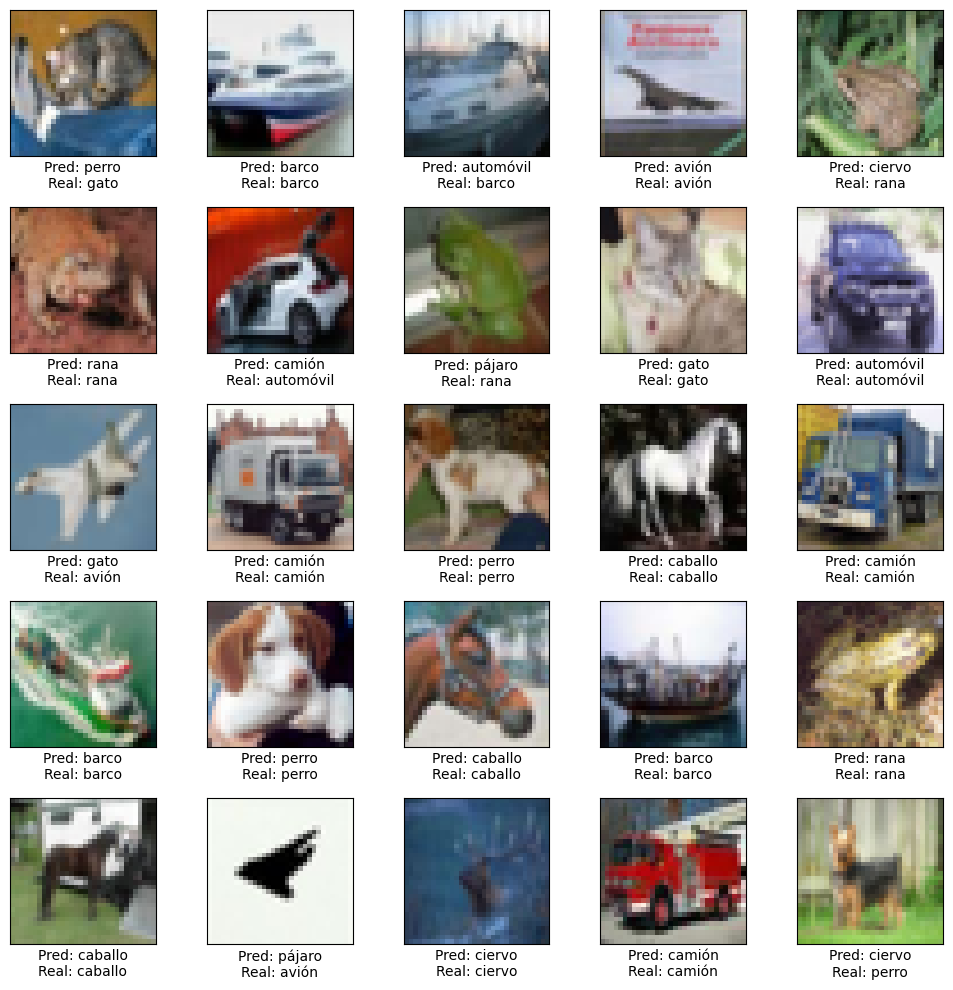

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Predecir
predicciones = modelo.predict(imagenes_prueba)
y_pred = np.argmax(predicciones, axis=1)
y_true = etiquetas_prueba.flatten()

# Clases
clases = ["avión", "automóvil", "pájaro", "gato", "ciervo",
          "perro", "rana", "caballo", "barco", "camión"]

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(imagenes_prueba[i])
    
    # Quitar ejes
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    # Etiquetas
    pred = clases[y_pred[i]]
    real = clases[y_true[i]]
    
    # Mostrar ambas
    plt.xlabel(f"Pred: {pred}\nReal: {real}")

plt.tight_layout()
plt.show()

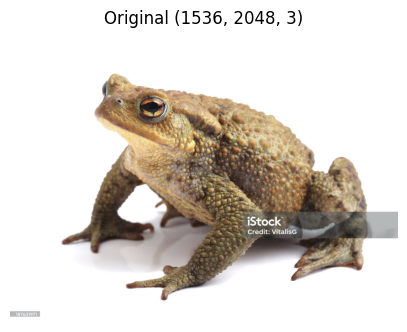

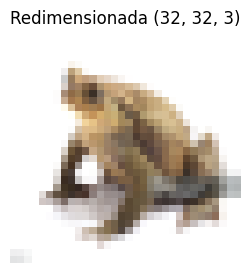

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# URL de la imagen
url = "https://media.istockphoto.com/id/187631971/es/foto/sapo-europea-aislado-en-blanco.jpg?s=2048x2048&w=is&k=20&c=3j_8tr0_oj9Hsa8ltyCmyIH7vDKgKigZLvfm_763KAo="

# Descargar imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Convertir a RGB (por si acaso)
img = img.convert('RGB')

# Convertir a arreglo
img_array = np.array(img)

# Mostrar imagen original
plt.figure(figsize=(5,5))
plt.imshow(img_array)
plt.title(f"Original {img_array.shape}")
plt.axis('off')
plt.show()

# Redimensionar a 32x32
img_resized = img.resize((32, 32))
img_resized_array = np.array(img_resized)

# Mostrar imagen redimensionada
plt.figure(figsize=(3,3))
plt.imshow(img_resized_array)
plt.title(f"Redimensionada {img_resized_array.shape}")
plt.axis('off')
plt.show()

In [37]:
# Normalizar imagen
img_normalizada = img_resized_array / 255.0

# Verificar valores
print("Mínimo:", img_normalizada.min())
print("Máximo:", img_normalizada.max())
print("Shape:", img_normalizada.shape)

Mínimo: 0.12549019607843137
Máximo: 1.0
Shape: (32, 32, 3)


In [38]:
import numpy as np

img_input = np.expand_dims(img_normalizada, axis=0)
# Predecir
predicciones = modelo.predict(img_input)

# Vector de probabilidades
print("Vector de probabilidades (softmax):")
print(predicciones[0])

# Clase predicha
clase_predicha = np.argmax(predicciones[0])

# Nombres de clases
clases = ["avión", "automóvil", "pájaro", "gato", "ciervo",
          "perro", "rana", "caballo", "barco", "camión"]

print("\nClase predicha:", clases[clase_predicha])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Vector de probabilidades (softmax):
[7.8470177e-05 9.2108396e-15 4.6777287e-11 8.2197424e-04 4.5173305e-08
 1.2704474e-01 8.7205434e-01 2.6637040e-11 1.0450254e-07 2.6487180e-07]

Clase predicha: rana


In [39]:
modelo.save("modelo_cifar10.keras")